# **Atividade Prática**
<font size=3>

- **Tema:** tarefa de classificação.
- **Prazo de entrega:** 01 de Junho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Enunciado:**
<font size=3>

Vamos realizar uma tarefa de **análise de sentimentos** com o conjundo de dados [IMDB movie reviews](https://keras.io/api/datasets/imdb/), também disponível no diretório $\text{dataset/}\,$. Realize os seguintes passos para resolver a **tarefa de classificação**:

### **1º Passo:**
<font size=3>

- Importe o *dataset*, embaralhe as amostras, e defina os dados textuais e alvo;
- **Plote** um histograma com os tamanhos das sentenças, a fim de definir um bom tamanho para a entrada do modelo.


### **Imports, variáveis globais e leitura do dataset**

In [1]:
# Não precisamos montar o drive pois os arquivos estão disponíveis localmente
#from google.colab import drive
#drive.mount('/content/drive/')

In [66]:
from collections import Counter
from keras import layers, Model
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.ticker import FuncFormatter
import os
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorboard
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

RANDOM_STATE = 42

In [3]:
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))
#tf.debugging.set_log_device_placement(True)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Lemos o dataset local, embaralhamos utilizando RANDOM_STATE como semente para garantir reprodutibilidade do experimento, e por fim mostramos o shape e uma pequena amostra dos datos.

In [4]:
df = pd.read_csv('./dataset/imdb.csv', ).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
df.head()

(50000, 2)


,reviews,label
0,River's Edge is more than just the story of a ...,1
1,Evening is the beautiful story of the flawed l...,1
2,I question anyone saying they don't care for t...,1
3,This docu-drama is what you would expect from ...,1
4,"As several posters have ""hinted,"" this is a so...",0


### Definindo uma função de pré-processamento para o texto

Definimos a função de pré-processamento no inicio para aplicá-la antes de analisar o tamanho das entradas. Assim operamos sobre um conjunto de dados limpo desde as definições preliminares.

In [5]:
def Preprocessor(x):

    # tudo em minúsculo
    x = tf.strings.lower(x)

    # remove tags html
    x = tf.strings.regex_replace(x, r"<[^>]+>", " ")

    # remove caracteres especiais
    x = tf.strings.regex_replace(x, r"[^\w\s]", "")

    # remove espaços em excesso
    x = tf.strings.regex_replace(x, r" {2,}", " ")

    # remove espaços extras no início e no final
    x = tf.strings.strip(x)

    return x

print (Preprocessor("   Hello,   the  world's  !   ").numpy().decode("utf-8"))

hello the worlds


2026-05-31 17:55:41.380007: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-05-31 17:55:41.380029: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-31 17:55:41.380035: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1780260941.380047  547783 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780260941.380064  547783 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Agora utilizamos a função de processamento para limpar o dataset.

In [6]:
df_clean = df.copy()

df_clean["reviews"] = df_clean["reviews"].apply(
    lambda x: Preprocessor(x).numpy().decode("utf-8")
)

df_clean.head()

,reviews,label
0,rivers edge is more than just the story of a m...,1
1,evening is the beautiful story of the flawed l...,1
2,i question anyone saying they dont care for th...,1
3,this docudrama is what you would expect from r...,1
4,as several posters have hinted this is a sorry...,0


Mas definimos `X` e `y` em função do dataset original `df`, pois vamos adicionar a função de pré-processamento no pipeline.

In [7]:
X = df["reviews"]
y = df["label"]

### Analisando a limpeza dos textos (função de `Preprocessor`)

Primeiro uma revisão básica do dataset

In [8]:
print(f"Quantidade de amostras: {len(df_clean)}")

print("\nValores ausentes:")
print(df_clean[["reviews", "label"]].isna().sum())

print("\nReviews vazias após a limpeza:")
print((df_clean["reviews"].str.len() == 0).sum())

print("\nDistribuição das classes:")
print(y.value_counts())

Quantidade de amostras: 50000

Valores ausentes:
reviews    0
label      0
dtype: int64

Reviews vazias após a limpeza:
0

Distribuição das classes:
label
1    25000
0    25000
Name: count, dtype: int64


Podemos observar 50.000 amostras perfeitamente balanceadas nas classes 0 e 1. Não existem valores vazios ou nulos no dataset.

Vamos observar então os tokens/palavras mais comuns no texto para analisar se existe necessidade de adicionar alguma funcionalidade na função de pré-processamento.
Analisando os dados decidimos adicionar a eliminação de tags HTML na função de pré-processamento. Abaixo mostramos apenas o resultado final.

In [ ]:
tokens = " ".join(df_clean["reviews"]).split()
token_counts = Counter(tokens)

token_counts.most_common(200)

[('the', 663910),
 ('and', 320683),
 ('a', 320571),
 ('of', 288481),
 ('to', 266928),
 ('is', 210499),
 ('in', 185063),
 ('it', 154901),
 ('i', 152108),
 ('this', 149898),
 ('that', 136535),
 ('was', 95403),
 ('as', 91242),
 ('with', 87003),
 ('for', 86834),
 ('movie', 85220),
 ('but', 81777),
 ('film', 76026),
 ('on', 66999),
 ('not', 60051),
 ('you', 59816),
 ('are', 58258),
 ('his', 57305),
 ('have', 55111),
 ('be', 52917),
 ('he', 51962),
 ('one', 51475),
 ('its', 49118),
 ('at', 46541),
 ('all', 45705),
 ('by', 44174),
 ('an', 42830),
 ('they', 41548),
 ('from', 40373),
 ('who', 40188),
 ('so', 39637),
 ('like', 39061),
 ('or', 34950),
 ('just', 34872),
 ('her', 34489),
 ('about', 34055),
 ('if', 33590),
 ('out', 33050),
 ('has', 32927),
 ('some', 31004),
 ('there', 30839),
 ('what', 30317),
 ('good', 28912),
 ('when', 27892),
 ('more', 27869),
 ('very', 27598),
 ('my', 24762),
 ('even', 24581),
 ('no', 24459),
 ('up', 24457),
 ('would', 24036),
 ('time', 23958),
 ('she', 23894),


### Definindo `MAX_LENGTH`

Agora que chegamos numa limpeza aparentemente razoável, vamos ver o tamanho das sentenças. Primeiro definimos uma coluna `length` no dataset `df_clean` para analisar sua distribuição numérica.

In [10]:
df_clean["length"] = df_clean["reviews"].str.split().str.len()

Criamos funções auxiliares para descrever a variável numérica.

In [11]:
def br_number(value, decimals=0):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")

In [12]:
def descrever_variavel_numerica(y, nome="variável", decimals=0):
    '''
    Descreve uma variável numérica com percentis e assimetria.
    '''
    percentis = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]

    print(f"=== Percentis de {nome} ===")

    for p in percentis:
        valor = y.quantile(p)
        qtd_acumulada = (y <= valor).sum()

        print(
            f"P {int(p * 100):>3}%:"
            f" {br_number(valor, decimals):>15}"
            f" | qtd acumulada: {qtd_acumulada:>5}"
        )

    print()

    print(f"=== Assimetria de {nome} ===")
    print(f"{'Média':<10}: {br_number(y.mean(), decimals):>15}")
    print(f"{'Mediana':<10}: {br_number(y.median(), decimals):>15}")
    print(f"{'Mínimo':<10}: {br_number(y.min(), decimals):>15}")
    print(f"{'Máximo':<10}: {br_number(y.max(), decimals):>15}")
    print(f"{'Skewness':<10}: {br_number(y.skew(), 2):>15}")
    print()

E utilizamos as funções definidas para descrever o tamanho das sentenças:

In [13]:
descrever_variavel_numerica(
    df_clean["length"],
    nome="tamanho das reviews",
    decimals=0
)

=== Percentis de tamanho das reviews ===
P   0%:               4 | qtd acumulada:     1
P   1%:              41 | qtd acumulada:   537
P   5%:              62 | qtd acumulada:  2528
P  10%:              88 | qtd acumulada:  5033
P  25%:             125 | qtd acumulada: 12746
P  50%:             171 | qtd acumulada: 25117
P  75%:             276 | qtd acumulada: 37507
P  90%:             445 | qtd acumulada: 45019
P  95%:             581 | qtd acumulada: 47503
P  99%:             892 | qtd acumulada: 49500
P 100%:           2.459 | qtd acumulada: 50000

=== Assimetria de tamanho das reviews ===
Média     :             228
Mediana   :             171
Mínimo    :               4
Máximo    :           2.459
Skewness  :            2,17



A distribuição do tamanho das reviews apresenta assimetria à direita. A mediana é de 171 palavras, enquanto a média é de 228 palavras, diferença pode ser explicada pela presença de reviews mais longas na distribuição. O coeficiente de assimetria (skewness) de 2,17 confirma esse comportamento. Em relação aos percentis, 75% das reviews possuem até 276 palavras, 90% possuem até 445 palavras e 95% possuem até 581 palavras. Embora a maior review contenha 2.459 palavras, os valores extremos representam uma parcela pequena do conjunto: apenas 1% das reviews ultrapassa 892 palavras. Esses resultados indicam que a definição do tamanho máximo da entrada deve priorizar os percentis intermediários, evitando dimensionar o modelo com base nos casos extremos e reduzindo a quantidade desnecessária de preenchimento (padding) nas sequências menores.


Para confirmar isso vamos produzir um gráfico de distribuição da quantidade de palavras no dataset. Primeiro definimos funções auxiliares para criar o gráfico.

In [14]:
def formatar_milhoes_br(x, pos):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    return f"{x / 1_000_000:.1f}".replace(".", ",")


def plotar_histograma_com_percentis(
    y,
    nome="variável",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=True
):
    '''
    Plota um histograma dos dados, juntamente com os percentis que desejamos marcar no grafico.
    '''
    limite = y.quantile(limite_percentil)
    y_filtrado = y[y <= limite]

    plt.figure(figsize=(12, 6))
    plt.hist(y_filtrado, bins=bins, edgecolor="black", alpha=0.7)

    if usar_milhoes:
        plt.gca().xaxis.set_major_formatter(FuncFormatter(formatar_milhoes_br))
        xlabel = f"{nome} em milhões"
    else:
        xlabel = nome

    altura_max = plt.ylim()[1]

    for p in percentis_marcados:
        valor = y.quantile(p)

        if valor <= limite:
            plt.axvline(valor, linestyle="--", linewidth=1.5, alpha=0.8)
            plt.text(
                valor,
                altura_max * 0.95,
                f"P{int(p * 100)}",
                rotation=90,
                ha="center",
                va="top"
            )

    plt.title(f"Distribuição de {nome} até o percentil {int(limite_percentil * 100)}")
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

Depois utilizamos a função para gerar o gráfico com a distribuição da quantidade de palavras por review do dataset.

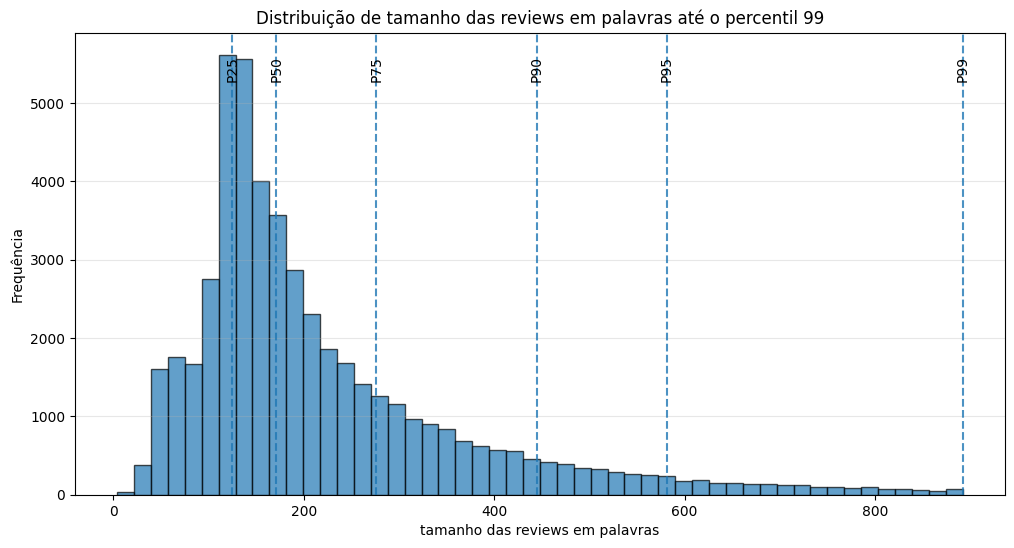

In [15]:
plotar_histograma_com_percentis(
    df_clean["length"],
    nome="tamanho das reviews em palavras",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=False
)

O histograma evidencia uma distribuição assimétrica à direita, com maior concentração de reviews entre aproximadamente 100 e 300 palavras e uma redução progressiva da frequência à medida que o tamanho aumenta. A presença de uma cauda longa indica que existem reviews significativamente maiores que a maioria, embora representem uma parcela reduzida do conjunto de dados.

Os percentis destacados no gráfico permitem observar esse comportamento de forma mais precisa. Enquanto 50% das reviews possuem até 171 palavras e 75% possuem até 276 palavras, o percentil 95 corresponde a 581 palavras. Isso significa que 95% das reviews possuem tamanho igual ou inferior a esse valor.

Dessa forma, foi escolhido o percentil 95 como referência para definir o tamanho máximo das entradas do modelo. Essa escolha permite preservar a maior parte do conteúdo textual disponível, ao mesmo tempo em que evita dimensionar todas as entradas com base em casos extremos. Reviews maiores que esse limite serão truncadas, enquanto reviews menores receberão preenchimento até o tamanho definido. Esse critério representa um equilíbrio entre retenção de informação e custo computacional.


In [16]:
MAX_LENGTH = int(df_clean["length"].quantile(0.95))

print(MAX_LENGTH)

581


### Definindo `VOCAB_SIZE`

Agora vamos avaliar a cobertura dos tokens em função do tamanho do vocabulário. O que queremos responder/definir é o seguinte: qual o tamanho do vocabulário nos permite extrair o máximo desempenho do dataset sem comprometer demais os recursos computacionais necessários para processamento?

Para isso vamos tentar mostrar, em termos de cobertura de vocabulário, qual o ganho marginal se obtém ao se aumentar o tamanho do vocabulário. Buscaremos identificar um ponto onde aumentar o tamanho do vocabulário gera um incremento marginal na cobertura.

Para isso, primeiro vamos contar a quantidade de tokens total e quantidade de tokens únicos do dataset.

In [17]:
# Conta todas as ocorrências de palavras no dataset pré-processado
token_counts = Counter(
    token
    for review in df_clean["reviews"]
    for token in review.split()
)

# Ordena os tokens do mais frequente para o menos frequente
frequencias_ordenadas = sorted(token_counts.values(), reverse=True)

total_ocorrencias = sum(frequencias_ordenadas)
total_tokens_unicos = len(frequencias_ordenadas)

print(f"Total de ocorrências de palavras: {br_number(total_ocorrencias)}")
print(f"Quantidade de palavras distintas: {br_number(total_tokens_unicos)}")

Total de ocorrências de palavras: 11.395.898
Quantidade de palavras distintas: 167.168


E definir alguns valores-alvo de vocab_size para averiguar a cobertura.

In [18]:
vocab_sizes = [
     1000,
     2000,
     5000,
    10000,
    15000,
    20000,
    30000,
    50000
]

Agora, para verificar a cobertura, vamos criar um dataset contendo, para cada um dos `vocab_size` propostos, a quantidade e percentual de ocorrências cobertas, e a quantidade e percentual de ocorrências fora do vocabulário (OOV: Out Of Vocabulary).

In [19]:
resultados_vocabulario = []

for vocab_size in vocab_sizes:
    tamanho_efetivo = min(vocab_size, total_tokens_unicos)

    ocorrencias_cobertas = sum(frequencias_ordenadas[:tamanho_efetivo])
    ocorrencias_oov = total_ocorrencias - ocorrencias_cobertas

    resultados_vocabulario.append({
        "VOCAB_SIZE": vocab_size,
        "palavras incluídas": tamanho_efetivo,
        "ocorrências cobertas": ocorrencias_cobertas,
        "cobertura (%)": ocorrencias_cobertas / total_ocorrencias * 100,
        "ocorrências OOV": ocorrencias_oov,
        "OOV (%)": ocorrencias_oov / total_ocorrencias * 100
    })

df_vocabulario = pd.DataFrame(resultados_vocabulario)

df_vocabulario.style.format({
    "VOCAB_SIZE": "{:,.0f}",
    "palavras incluídas": "{:,.0f}",
    "ocorrências cobertas": "{:,.0f}",
    "cobertura (%)": "{:.2f}",
    "ocorrências OOV": "{:,.0f}",
    "OOV (%)": "{:.2f}"
})

,VOCAB_SIZE,palavras incluídas,ocorrências cobertas,cobertura (%),ocorrências OOV,OOV (%)
0,"1,000","1,000","8,649,734",75.90,"2,746,164",24.10
1,"2,000","2,000","9,375,607",82.27,"2,020,291",17.73
2,"5,000","5,000","10,187,270",89.39,"1,208,628",10.61
3,"10,000","10,000","10,660,796",93.55,"735,102",6.45
4,"15,000","15,000","10,875,801",95.44,"520,097",4.56
5,"20,000","20,000","11,000,147",96.53,"395,751",3.47
6,"30,000","30,000","11,134,286",97.70,"261,612",2.30
7,"50,000","50,000","11,245,722",98.68,"150,176",1.32


Os resultados mostram que a cobertura cresce rapidamente até aproximadamente 10.000 palavras e passa a apresentar ganhos marginais progressivamente menores a partir desse ponto. Com 10.000 palavras, o vocabulário cobre 93,55% das ocorrências do corpus, deixando 6,45% como tokens fora do vocabulário. Ao aumentar para 15.000, a cobertura sobe para 95,44%, um ganho de 1,89 ponto percentual. Com 20.000, a cobertura chega a 96,53%, representando ganho adicional de apenas 1,09 ponto percentual. A partir daí, o crescimento se torna ainda menos expressivo: usar 50.000 palavras eleva a cobertura para 98,68%, mas exige uma matriz de embeddings cinco vezes maior que a configuração com 10.000.

Vamos visualizar essa curva num gráfico para definir o tamanho do vocabulario que será utilizado.

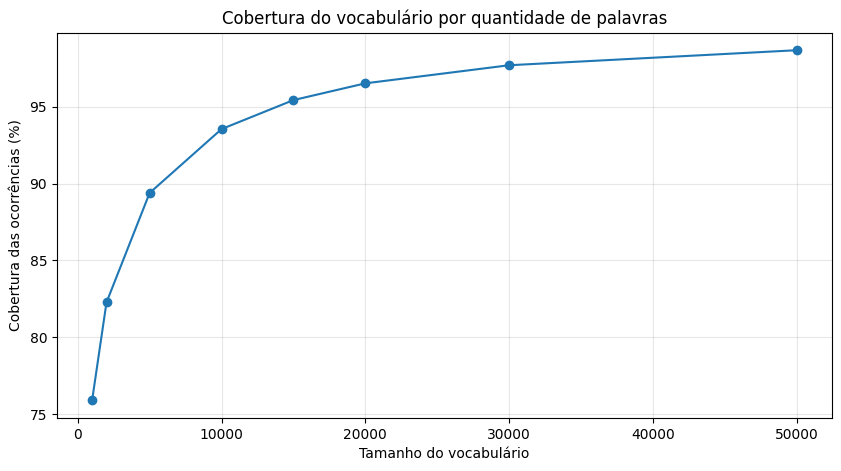

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_vocabulario["VOCAB_SIZE"],
    df_vocabulario["cobertura (%)"],
    marker="o"
)

plt.title("Cobertura do vocabulário por quantidade de palavras")
plt.xlabel("Tamanho do vocabulário")
plt.ylabel("Cobertura das ocorrências (%)")
plt.grid(True, alpha=0.3)

plt.show()

O gráfico indica um ponto de inflexão entre 10.000 e 15.000 palavras. Considerando o equilíbrio entre cobertura do vocabulário, custo computacional e quantidade de parâmetros, 15.000 nos parece uma escolha mais adequada para nosso caso. Esse valor cobre pouco mais de 95% das ocorrências e reduz a proporção de tokens desconhecidos para 4,56%, sem aumentar excessivamente a complexidade do modelo.

In [21]:
VOCAB_SIZE = 15000

### **2º Passo:**
<font size=3>

- Realize a transformação da variável alvo;
- Defina o objeto da vetorização dos dados textuais com a função [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/):
    - Faça operações *regex* customizadas, caso seja necessário.
    - Defina o tamanho do vocabulário (`vocab_size`), o tamanho da entrada/janela do modelo (`max_len`), e a dimensão do vetor *embedding* (`embed_dim`);
    - Iremos realizar a vetorização (indexação) dentro da rede neural, ou seja, o objeto da vetorização irá processar os dados após a camada `layers.Input()`.
    <br>

- Divida os dados em treninamento (90%) e teste (10%). Os dados de validação serão divididos na função `model.fit()`.  

A definição das operações de limpeza dos dados (`Preprocessor`), do tamanho de entrada do modelo (`MAX_LENGTH=581`) e do tamanho do vocabulário (`VOCAB_SIZE=15000`) foram realizadas e justificadas no passo anterior.

Ja o número de dimensões do embedding não pode ser definido exclusivamente em função do vocabulário. Ele deve ser tratado como um hiperparâmetro do modelo e deve ser definido em função do desempenho do modelo. Poucas dimensões podem não ser suficientes para representar adequadamente a relação entre as palavras; muitas dimensões podem gerar overfitting; portanto, vamos iniciar com um valor mais ou menos arbitrário, moderado, que nos permita testar o modelo: `EMBED_DIM = 100`. Inclusive, por que esse valor inicial nos permitirá utilizar os embeddings pre-treinados do GloVe com mais facilidade, caso seja desejado.

In [22]:
#EMBED_DIM = 100 

vectorizer = layers.TextVectorization(
    name="TextVectorizer",
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LENGTH,
    standardize=Preprocessor,
    output_mode="int",
)

Agora definimos o conjunto de treino e teste do nosso dataset, tomando o cuidado de manter a estratificação das classes.

In [23]:
TEST_SIZE = 0.10

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)


E confirmamos que a estratificação foi corretamente mantida.

In [24]:
def comparar_distribuicao_classes(
    y_total,
    y_treino,
    y_avaliacao,
    nome_treino="Treino",
    nome_avaliacao="Teste"
):
    distribuicao_classes = pd.DataFrame({
        "Total - qtd": y_total.value_counts().sort_index(),
        "Total - %": y_total.value_counts(normalize=True).sort_index() * 100,
        f"{nome_treino} - qtd": y_treino.value_counts().sort_index(),
        f"{nome_treino} - %": y_treino.value_counts(normalize=True).sort_index() * 100,
        f"{nome_avaliacao} - qtd": y_avaliacao.value_counts().sort_index(),
        f"{nome_avaliacao} - %": y_avaliacao.value_counts(normalize=True).sort_index() * 100
    })

    distribuicao_classes.index.name = "Classe"

    return distribuicao_classes.style.format({
        "Total - qtd": "{:,.0f}",
        "Total - %": "{:.2f}%",
        f"{nome_treino} - qtd": "{:,.0f}",
        f"{nome_treino} - %": "{:.2f}%",
        f"{nome_avaliacao} - qtd": "{:,.0f}",
        f"{nome_avaliacao} - %": "{:.2f}%"
    })

In [25]:
comparar_distribuicao_classes(
    y_total=y,
    y_treino=y_train,
    y_avaliacao=y_test
)

,Total - qtd,Total - %,Treino - qtd,Treino - %,Teste - qtd,Teste - %
Classe,,,,,,
0,"25,000",50.00%,"22,500",50.00%,"2,500",50.00%
1,"25,000",50.00%,"22,500",50.00%,"2,500",50.00%


Dessa forma, temos os dados definidos em `X_train`, `X_test`, `y_train` e `y_test` mantendo a estratificação das classes e com o percentual de 10% para teste conforme solicitado.

### **3º Passo:**
<font size=3>

- Desenvolva a primeira versão da **arquitetura neural**:
    - Já sabemos o tamanho da entrada, o tamanho da saída e sua função de ativação:
 
        <font size=2>
        
        ```python
        x_in = layers.Input(shape=(1, ), dtype=tf.string)
            
        ```
        <font size=3>
        
    - A camada [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) irá retornar um *array* de formato (`max_len`, `embed_dim`), assim, precisamos torná-lo unidimensional para poder ser acoplado à próxima camada. Para isso, utilize:
        - Uma camada de [`Flatten`](https://keras.io/api/layers/reshaping_layers/flatten/);
        - Ou uma camada de [`GlobalAveragePooling1D`](https://keras.io/api/layers/pooling_layers/global_average_pooling1d/).
        <br>

- Compile o modelo com um otimizador ([`SGR`](https://keras.io/api/optimizers/sgd/), [`RMSprop`](https://keras.io/api/optimizers/rmsprop/), [`Adam`](https://keras.io/api/optimizers/adam/));
- Defina a função de perda e métrica de acordo com a natureza do problema.
  

Primeiro vamos dividos os dados de treinamento em treino (tune) e validação, novamente com percentual de 10%.

In [26]:
VALIDATION_SIZE = 0.10

X_tune_train, X_val, y_tune_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

comparar_distribuicao_classes(
    y_total=y_train,
    y_treino=y_tune_train,
    y_avaliacao=y_val,
    nome_treino="Treino para busca",
    nome_avaliacao="Validação"
)

,Total - qtd,Total - %,Treino para busca - qtd,Treino para busca - %,Validação - qtd,Validação - %
Classe,,,,,,
0,"22,500",50.00%,"20,250",50.00%,"2,250",50.00%
1,"22,500",50.00%,"20,250",50.00%,"2,250",50.00%


Preparamos os dados para executar o treinamento.

In [27]:
X_tune_train_array = tf.convert_to_tensor(
    X_tune_train.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

X_val_array = tf.convert_to_tensor(
    X_val.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

y_tune_train_array = tf.convert_to_tensor(
    y_tune_train.to_numpy(),
    dtype=tf.float32
)

y_val_array = tf.convert_to_tensor(
    y_val.to_numpy(),
    dtype=tf.float32
)

In [28]:
print(f"Treino para busca : {X_tune_train_array.shape}")
print(f"Validação         : {X_val_array.shape}")
print(f"Teste reservado   : {len(X_test)}")

Treino para busca : (40500, 1)
Validação         : (4500, 1)
Teste reservado   : 5000


E criamos o vetorizador utilizando os parametros que definimos anteriormente (`VOCAB_SIZE=15.000` e `MAX_LENGTH=581`).

In [29]:
vectorizer = layers.TextVectorization(
    standardize=Preprocessor,
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

vectorizer.adapt(X_tune_train_array)

print(f"Tamanho efetivo do vocabulário: {vectorizer.vocabulary_size()}")

Tamanho efetivo do vocabulário: 15000


Ao invés de executar e treinar alguns poucos modelos, vamos adotar uma abordagem mais sistematizada para definição do modelo. Trabalharemos com RandomSearch e GridSearch e trataremos alguns hiperparâmetros do modelo com essas buscas. Para isso, vamos utilizar Keras Tuner com uma busca randômica preliminar e os seguintes hiperparâmetros:

- embed_dim = [50, 100, 200]
- dense_units = [16, 32, 64]
- dropout_rate = [0.0, 0.2, 0.4]
- optimizer = ["adam", "rmsprop", "sgd"]
- learning_rate = [1e-2, 1e-3, 1e-4]

Isso nos dá um espaço de busca com 243 combinações possíveis. Vamos utilizar early stopping com patience = 3 e apenas 12 execuções. Isso nos dará uma cobertura de aproximadamente 5% do espaço, o que é baixo. Mas como é uma busca preliminar, vamos analisar os resultados obtidos para definir uma segunda busca com as configurações mais promissoras posteriormente.

In [30]:
def build_model(hp):

    embed_dim = hp.Choice(
        "embed_dim",
        values=[50, 100, 200]
    )

    dense_units = hp.Choice(
        "dense_units",
        values=[16, 32, 64]
    )

    dropout_rate = hp.Choice(
        "dropout_rate",
        values=[0.0, 0.2, 0.4]
    )

    optimizer_name = hp.Choice(
        "optimizer",
        values=["adam", "rmsprop", "sgd"]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-2, 1e-3, 1e-4]
    )

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="review"
    )

    x = vectorizer(x_in)

    x = layers.Embedding(
        input_dim=vectorizer.vocabulary_size(),
        output_dim=embed_dim,
        mask_zero=True,
        name="embedding"
    )(x)

    x = layers.GlobalAveragePooling1D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        units=dense_units,
        activation="relu",
        name="hidden"
    )(x)

    x = layers.Dropout(
        rate=dropout_rate,
        name="dropout"
    )(x)

    y_out = layers.Dense(
        units=1,
        activation="sigmoid",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=x_in,
        outputs=y_out
    )

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )
    else:
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    )

    return model

Definimos nosso random search e exibimos um sumário do espaço de busca.

In [31]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=12,
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_results",
    project_name="imdb_sentiment_initial",
    seed=RANDOM_STATE
)

tuner.search_space_summary()

Search space summary
Default search space size: 5
embed_dim (Choice)
{'default': 50, 'conditions': [], 'values': [50, 100, 200], 'ordered': True}
dense_units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout_rate (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.2, 0.4], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


Definimos o early stopping e executamos a busca.

In [32]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir="keras_tuner_logs"
)

tuner.search(
    X_tune_train_array,
    y_tune_train_array,
    validation_data=(X_val_array, y_val_array),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stopping,
        tensorboard_callback
    ],
    shuffle=True,
    verbose=1
)

Trial 12 Complete [00h 00m 55s]
val_accuracy: 0.8955555558204651

Best val_accuracy So Far: 0.9017778038978577
Total elapsed time: 00h 29m 01s


Por fim, montamos um dataset com os resultados de cada uma das 12 execuções.

In [35]:
resultados_trials = []

for trial in tuner.oracle.trials.values():
    resultados_trials.append({
        "trial_id": trial.trial_id,
        "status": trial.status,
        "val_accuracy": trial.score,
        "melhor_epoca": trial.best_step + 1 if trial.best_step is not None else None,
        **trial.hyperparameters.values
    })

df_trials = (
    pd.DataFrame(resultados_trials)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)

df_trials

,trial_id,status,val_accuracy,melhor_epoca,embed_dim,dense_units,dropout_rate,optimizer,learning_rate
0,08,COMPLETED,0.901778,16,50,32,0.4,adam,0.0001
1,00,COMPLETED,0.901111,15,100,16,0.2,adam,0.0001
2,02,COMPLETED,0.900222,10,200,32,0.4,adam,0.0001
3,07,COMPLETED,0.895778,1,200,64,0.0,adam,0.0010
4,11,COMPLETED,0.895556,2,50,32,0.2,adam,0.0010
5,03,COMPLETED,0.893333,2,50,32,0.0,adam,0.0010
6,06,COMPLETED,0.886444,4,50,16,0.4,rmsprop,0.0010
7,04,COMPLETED,0.885333,2,200,32,0.2,rmsprop,0.0100
8,01,COMPLETED,0.884889,3,100,32,0.0,rmsprop,0.0100
9,09,COMPLETED,0.878222,3,50,32,0.0,adam,0.0100


Nosso random search preliminar nos permite tirar algumas conclusões e direcionar uma segunda busca:

1. **Otimizador**: `Adam` foi claramente superior: para a próxima rodada podemos descartar sgd e rmsprop.
2. **Learning Rate**: `1e-4` apresentou melhores resultados, mas acreditamos que podemos explorar alguns valores próximos.
3. **Dimensão de Embeddings**: `embed_dim` maiores não geraram melhores resultados. Na verdade a diferença entre eles foi praticamente irrelevante. Vamos trabalhar apenas `embed_dim = 50` na próxima etapa.
4. **Tamanho da Camada Densa**: embora `dense_units = 32` tenha gerado a melhor execução, não houve uma clara dominancia dessa configuração sobre as demais. Vamos seguir explorando esse parâmetro na seguinte rodada.
5. **Dropout**: também não houve clara dominância de alguma configuração nesse parâmetro. Entretanto, podemos observar que o valor de dropout = 0.0 não parece muito promissor com o otimizador Adam. Portanto, vamos descartar essa opção nas próxima rodada.

### **4º Passo:**
<font size=3>

- Treine o modelo com o método `.fit()`, definindo as variáveis:
    - `validation_split`: porcentagem de dados para validação;
    - `epochs`: número de épocas para o treinamento;
    - `batch_size`: tamanho do lote da amostragem dos dados de entrada.

Considerando as observações anteriores, vamos definir uma segunda rodada com as seguintes configurações:

- embed_dim = [50]
- dense_units = [16, 32, 64]
- dropout_rate = [0.2, 0.3, 0.4, 0.5]
- optimizer = ["adam"]
- learning_rate = [5e-5, 1e-4, 2e-4]

Como agora temos um espaço mais reduzido, 36 opções apenas, vamos modificar a estratégia e executar um GridSearch para explorar todo o espaço de busca. Vamos manter  early stopping, mas ajustando patience para 4, já que estamos testando leaning rates menores, o que pode levar os modelos a aprenderem mais devagar. Redefinimos a função build_model para operar com o novo espaço de busca.

In [36]:
def build_model(hp):

    embed_dim = 50

    dense_units = hp.Choice(
        "dense_units",
        values=[16, 32, 64]
    )

    dropout_rate = hp.Choice(
        "dropout_rate",
        values=[0.2, 0.3, 0.4, 0.5]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[5e-5, 1e-4, 2e-4]
    )

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="review"
    )

    x = vectorizer(x_in)

    x = layers.Embedding(
        input_dim=vectorizer.vocabulary_size(),
        output_dim=embed_dim,
        mask_zero=True,
        name="embedding"
    )(x)

    x = layers.GlobalAveragePooling1D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        units=dense_units,
        activation="relu",
        name="hidden"
    )(x)

    x = layers.Dropout(
        rate=dropout_rate,
        name="dropout"
    )(x)

    y_out = layers.Dense(
        units=1,
        activation="sigmoid",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=x_in,
        outputs=y_out
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    )

    return model

Agora definimos o tuner (GridSearch) e early stopping com patience = 4 pois agora estamos trabalhando com valores de learning rate menores. Por fim executamos a busca.

In [37]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=36,
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_results",
    project_name="imdb_sentiment_refined"
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True
)

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir="keras_tuner_logs/imdb_sentiment_refined"
)

tuner.search(
    X_tune_train_array,
    y_tune_train_array,
    validation_data=(X_val_array, y_val_array),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stopping,
        tensorboard_callback
    ],
    shuffle=True,
    verbose=1
)

Trial 36 Complete [00h 02m 13s]
val_accuracy: 0.9006666541099548

Best val_accuracy So Far: 0.9026666879653931
Total elapsed time: 02h 27m 58s


Agora geramos uma tabela com todos os resultados resumidos.

In [38]:
resultados_grid = []

for trial in tuner.oracle.trials.values():
    resultados_grid.append({
        "trial_id": trial.trial_id,
        "status": trial.status,
        "val_accuracy": trial.score,
        "melhor_epoca": trial.best_step + 1 if trial.best_step is not None else None,
        "dense_units": trial.hyperparameters.get("dense_units"),
        "dropout_rate": trial.hyperparameters.get("dropout_rate"),
        "learning_rate": trial.hyperparameters.get("learning_rate")
    })

df_grid = (
    pd.DataFrame(resultados_grid)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)

df_grid.insert(
    0,
    "posição",
    range(1, len(df_grid) + 1)
)

df_grid

,posição,trial_id,status,val_accuracy,melhor_epoca,dense_units,dropout_rate,learning_rate
0,1,16,COMPLETED,0.902667,14,32,0.3,0.00010
1,2,09,COMPLETED,0.902667,41,16,0.5,0.00005
2,3,10,COMPLETED,0.902444,19,16,0.5,0.00010
3,4,34,COMPLETED,0.902000,14,64,0.5,0.00010
4,5,24,COMPLETED,0.902000,24,64,0.2,0.00005
5,6,11,COMPLETED,0.901778,9,16,0.5,0.00020
6,7,19,COMPLETED,0.901556,17,32,0.4,0.00010
7,8,01,COMPLETED,0.901556,17,16,0.2,0.00010
8,9,13,COMPLETED,0.901556,15,32,0.2,0.00010
9,10,27,COMPLETED,0.901333,30,64,0.3,0.00005


Agora que treinamos os 36 modelos, vamos diminuir patience para 3 e treinar novamente apenas os top 6 modelos em termos de acurácia. Decidimos diminuir patience por que não parece que houve ganho significativo no aumento do tempo de espera para atuação do early stopping. 

Em seguida vamos gerar graficos de acurácia e loss ao longo das épocas de treinamento e escolher o modelo que será utilizado nos passos seguintes. 

Vale lembrar que os resultados numéricos podem ser ligeiramente distintos por conta da nova inicialização dos pesos do modelo.

In [49]:
def retreinar_e_plotar_melhores_modelos(
    tuner,
    build_model,
    X_train,
    y_train,
    X_val,
    y_val,
    top_n=3,
    epochs=50,
    batch_size=64,
    patience=4,
    random_state=42
):
    """
    Retreina os melhores modelos encontrados pelo tuner e plota seus históricos.

    Para cada modelo, gera dois gráficos lado a lado:
    - acurácia de treino e validação;
    - loss de treino e validação.

    A época com maior val_accuracy é marcada por uma linha vertical pontilhada.

    Todos os gráficos usam a mesma escala no eixo x, de 1 até `epochs`,
    permitindo comparação visual direta entre os modelos.

    Parameters
    ----------
    tuner : keras_tuner.Tuner
        Tuner previamente executado.

    build_model : callable
        Função utilizada para construir o modelo a partir dos hiperparâmetros.

    X_train, y_train
        Dados de treino utilizados durante a busca.

    X_val, y_val
        Dados de validação utilizados durante a busca.

    top_n : int
        Quantidade de melhores modelos que serão retreinados.

    epochs : int
        Quantidade máxima de épocas por treinamento.

    batch_size : int
        Quantidade de amostras em cada batch.

    patience : int
        Quantidade de épocas sem melhora antes da interrupção antecipada.

    random_state : int
        Semente utilizada para aumentar a reprodutibilidade.

    Returns
    -------
    dict
        Modelos, históricos e hiperparâmetros das novas execuções.
    """
    melhores_trials = tuner.oracle.get_best_trials(num_trials=top_n)

    resultados_retreino = {}

    fig, axes = plt.subplots(
        nrows=top_n,
        ncols=2,
        figsize=(16, 5 * top_n),
        squeeze=False
    )

    for indice, trial in enumerate(melhores_trials):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(random_state)

        trial_id = str(trial.trial_id).zfill(2)
        hp = trial.hyperparameters

        model = build_model(hp)

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping],
            shuffle=True,
            verbose=1
        )

        train_accuracy = history.history["accuracy"]
        val_accuracy = history.history["val_accuracy"]
        train_loss = history.history["loss"]
        val_loss = history.history["val_loss"]

        epocas = range(1, len(val_accuracy) + 1)

        melhor_epoca = int(tf.argmax(val_accuracy).numpy()) + 1
        melhor_val_accuracy = val_accuracy[melhor_epoca - 1]

        dense_units = hp.get("dense_units")
        dropout_rate = hp.get("dropout_rate")
        learning_rate = hp.get("learning_rate")

        parametros = (
            f"Trial {trial_id} | "
            f"dense={dense_units} | "
            f"dropout={dropout_rate:.1f} | "
            f"lr={learning_rate:.0e}"
        )

        ax_accuracy = axes[indice, 0]
        ax_loss = axes[indice, 1]

        # Gráfico de acurácia
        ax_accuracy.plot(
            epocas,
            train_accuracy,
            label="Treino"
        )

        ax_accuracy.plot(
            epocas,
            val_accuracy,
            label="Validação"
        )

        ax_accuracy.axvline(
            melhor_epoca,
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label=f"Melhor época: {melhor_epoca}"
        )

        ax_accuracy.scatter(
            melhor_epoca,
            melhor_val_accuracy,
            zorder=3
        )

        ax_accuracy.set_title(
            f"{parametros}\n"
            f"Evolução da acurácia | "
            f"melhor val_accuracy={melhor_val_accuracy:.4f}"
        )
        ax_accuracy.set_xlabel("Época")
        ax_accuracy.set_ylabel("Acurácia")
        ax_accuracy.set_xlim(1, epochs)
        ax_accuracy.grid(True, alpha=0.3)
        ax_accuracy.legend()

        # Gráfico de loss
        ax_loss.plot(
            epocas,
            train_loss,
            label="Treino"
        )

        ax_loss.plot(
            epocas,
            val_loss,
            label="Validação"
        )

        ax_loss.axvline(
            melhor_epoca,
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label=f"Melhor época: {melhor_epoca}"
        )

        ax_loss.set_title(
            f"{parametros}\n"
            f"Evolução da loss"
        )
        ax_loss.set_xlabel("Época")
        ax_loss.set_ylabel("Loss")
        ax_loss.set_xlim(1, epochs)
        ax_loss.grid(True, alpha=0.3)
        ax_loss.legend()

        resultados_retreino[trial_id] = {
            "modelo": model,
            "historico": history,
            "hiperparametros": {
                "dense_units": dense_units,
                "dropout_rate": dropout_rate,
                "learning_rate": learning_rate
            },
            "melhor_epoca": melhor_epoca,
            "melhor_val_accuracy": melhor_val_accuracy
        }

    plt.tight_layout()
    plt.show()

    return resultados_retreino

Epoch 1/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5784 - loss: 0.6906 - val_accuracy: 0.6402 - val_loss: 0.6866
Epoch 2/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6661 - loss: 0.6787 - val_accuracy: 0.7227 - val_loss: 0.6684
Epoch 3/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7180 - loss: 0.6540 - val_accuracy: 0.7764 - val_loss: 0.6361
Epoch 4/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7581 - loss: 0.6174 - val_accuracy: 0.8082 - val_loss: 0.5934
Epoch 5/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7799 - loss: 0.5753 - val_accuracy: 0.8256 - val_loss: 0.5476
Epoch 6/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7972 - loss: 0.5328 - val_accuracy: 0.8382 - val_loss: 0.5043
Epoch 7/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8117 - loss: 0.4951 - val_accuracy: 0.8491 - val_loss: 0.4662
Epoch 8/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8240 - loss: 0.4634 - 

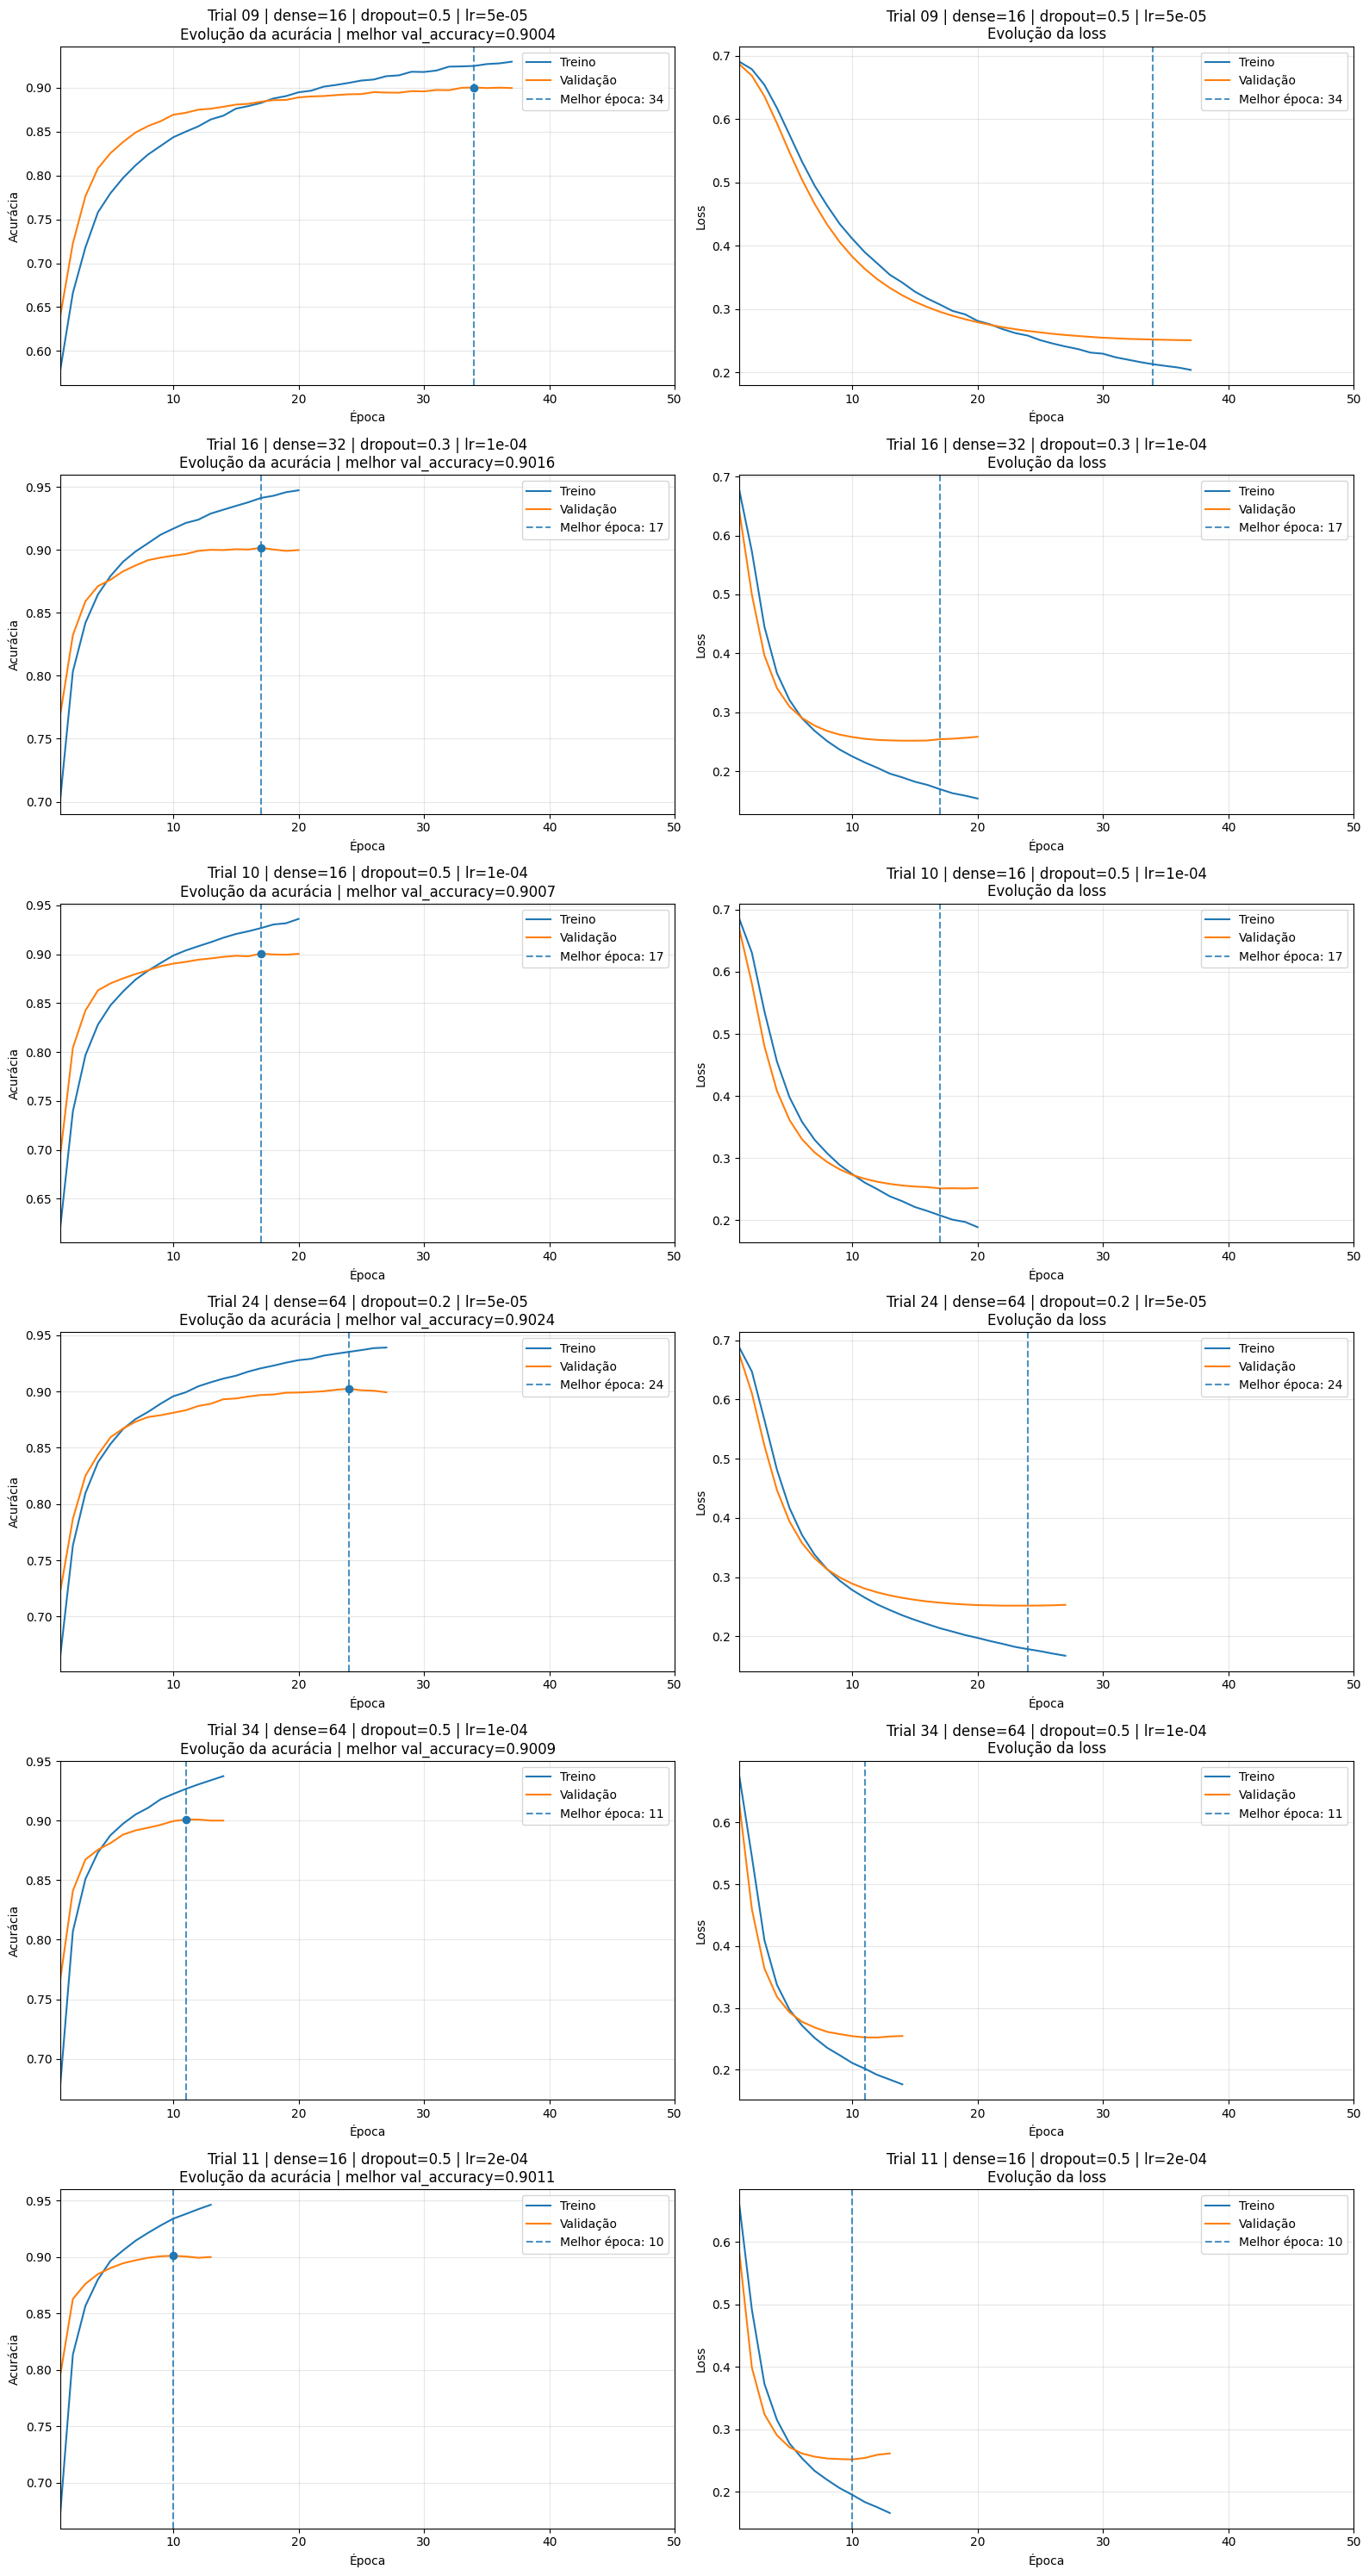

In [ ]:
resultados_retreino_topN = retreinar_e_plotar_melhores_modelos(
    tuner=tuner,
    build_model=build_model,
    X_train=X_tune_train_array,
    y_train=y_tune_train_array,
    X_val=X_val_array,
    y_val=y_val_array,
    top_n=6,
    epochs=50,
    batch_size=64,
    patience=3,
    random_state=RANDOM_STATE
)


Embora algumas configurações tenham apresentado acurácia de validação ligeiramente superior, de modo geral as diferenças observadas foram pequenas. Assim, vamos considerar na escolha do modelo final não apenas o melhor valor pontual de acurácia, mas também a estabilidade do treinamento, a complexidade da arquitetura e os sinais de overfitting.

Escolhemos o trial 09, modelo com `dense_units=16`, `dropout_rate=0,5` e `learning_rate=5e-5`. Essa configuração apresentou convergência mais gradual, menor diferença entre as curvas de treino e validação e comportamento mais estável da loss de validação. Além disso, utiliza uma camada densa menor e maior regularização por dropout, reduzindo a complexidade do modelo sem perda relevante de desempenho.

Portanto, a escolha prioriza um equilíbrio entre acurácia, capacidade de generalização e simplicidade arquitetural.


### **5º Passo:**
<font size=3>

- Quando definida uma boa arquitetura neural, faça o **treinamento final** do modelo com todos os dados de treinamento (sem validação).

In [54]:
# ============================================================
# Configuração do modelo final
# ============================================================

FINAL_EMBED_DIM = 50
FINAL_DENSE_UNITS = 16
FINAL_DROPOUT_RATE = 0.5
FINAL_LEARNING_RATE = 5e-5
FINAL_BATCH_SIZE = 64

# Melhor época observada para a configuração escolhida
FINAL_EPOCHS = 34


# ============================================================
# Conversão dos dados completos de treino
# ============================================================

X_train_final = tf.convert_to_tensor(
    X_train.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

y_train_final = tf.convert_to_tensor(
    y_train.to_numpy(),
    dtype=tf.float32
)

print(f"Formato de X_train_final: {X_train_final.shape}")
print(f"Formato de y_train_final: {y_train_final.shape}")

Formato de X_train_final: (45000, 1)
Formato de y_train_final: (45000,)


In [55]:
# ============================================================
# Vetorização final
# ============================================================

vectorizer_final = layers.TextVectorization(
    standardize=Preprocessor,
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

vectorizer_final.adapt(X_train_final)

print(
    f"Tamanho efetivo do vocabulário: "
    f"{vectorizer_final.vocabulary_size()}"
)

Tamanho efetivo do vocabulário: 15000


In [56]:
# ============================================================
# Construção do modelo final
# ============================================================

def criar_modelo_final():
    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="review"
    )

    x = vectorizer_final(x_in)

    x = layers.Embedding(
        input_dim=vectorizer_final.vocabulary_size(),
        output_dim=FINAL_EMBED_DIM,
        mask_zero=True,
        name="embedding"
    )(x)

    x = layers.GlobalAveragePooling1D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        units=FINAL_DENSE_UNITS,
        activation="relu",
        name="hidden"
    )(x)

    x = layers.Dropout(
        rate=FINAL_DROPOUT_RATE,
        name="dropout"
    )(x)

    y_out = layers.Dense(
        units=1,
        activation="sigmoid",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=x_in,
        outputs=y_out,
        name="imdb_sentiment_classifier"
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=FINAL_LEARNING_RATE
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            )
        ]
    )

    return model

In [57]:
# ============================================================
# Treinamento final
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

model_final = criar_modelo_final()

model_final.summary()

Model: "imdb_sentiment_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 581)       │          0 │ review[0][0]      │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 581, 50)   │    750,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 581)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 50)        │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden (Dense)      │ (None, 16)        │        816 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ hidden[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 750,833 (2.86 MB)

 Trainable params: 750,833 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:

history_final = model_final.fit(
    X_train_final,
    y_train_final,
    epochs=FINAL_EPOCHS,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    verbose=1
)

Epoch 1/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5674 - loss: 0.6903
Epoch 2/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6553 - loss: 0.6760
Epoch 3/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.7231 - loss: 0.6452
Epoch 4/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.7668 - loss: 0.5992
Epoch 5/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.7914 - loss: 0.5515
Epoch 6/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8097 - loss: 0.5055
Epoch 7/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8217 - loss: 0.4658
Epoch 8/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8336 - loss: 0.4336
Epoch 9/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8448 - loss: 0.4067
Epoch 10/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8529 - loss: 0.3826
Epoch 11/34
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8593 - loss: 0.3629
Epoch 12/34
704/704 ━━━━━━━━━━

In [61]:
import matplotlib.pyplot as plt


def plotar_historico_modelo_final(history):
    """
    Plota a evolução da acurácia e da loss do modelo final ao longo das épocas.

    Destaca numericamente os valores obtidos na última época.

    Parameters
    ----------
    history : keras.callbacks.History
        Histórico retornado pelo método model.fit().
    """
    accuracy = history.history["accuracy"]
    loss = history.history["loss"]

    epocas = range(1, len(loss) + 1)

    ultima_epoca = len(loss)
    accuracy_final = accuracy[-1]
    loss_final = loss[-1]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 5)
    )

    ax_accuracy, ax_loss = axes

    # ============================================================
    # Acurácia
    # ============================================================

    ax_accuracy.plot(
        epocas,
        accuracy,
        label="Treino"
    )

    ax_accuracy.scatter(
        ultima_epoca,
        accuracy_final,
        zorder=3
    )

    ax_accuracy.annotate(
        f"{accuracy_final:.4f}",
        xy=(ultima_epoca, accuracy_final),
        xytext=(-45, 15),
        textcoords="offset points",
        arrowprops={
            "arrowstyle": "->",
            "connectionstyle": "arc3"
        }
    )

    ax_accuracy.set_title(
        f"Evolução da acurácia do modelo final\n"
        f"Acurácia final: {accuracy_final:.4f}"
    )

    ax_accuracy.set_xlabel("Época")
    ax_accuracy.set_ylabel("Acurácia")
    ax_accuracy.set_xlim(1, ultima_epoca)
    ax_accuracy.grid(True, alpha=0.3)
    ax_accuracy.legend()

    # ============================================================
    # Loss
    # ============================================================

    ax_loss.plot(
        epocas,
        loss,
        label="Treino"
    )

    ax_loss.scatter(
        ultima_epoca,
        loss_final,
        zorder=3
    )

    ax_loss.annotate(
        f"{loss_final:.4f}",
        xy=(ultima_epoca, loss_final),
        xytext=(-45, 15),
        textcoords="offset points",
        arrowprops={
            "arrowstyle": "->",
            "connectionstyle": "arc3"
        }
    )

    ax_loss.set_title(
        f"Evolução da loss do modelo final\n"
        f"Loss final: {loss_final:.4f}"
    )

    ax_loss.set_xlabel("Época")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_xlim(1, ultima_epoca)
    ax_loss.grid(True, alpha=0.3)
    ax_loss.legend()

    plt.tight_layout()
    plt.show()

    print("=== Métricas finais de treino ===")
    print(f"Época final : {ultima_epoca}")
    print(f"Acurácia    : {accuracy_final:.4f}")
    print(f"Loss        : {loss_final:.4f}")

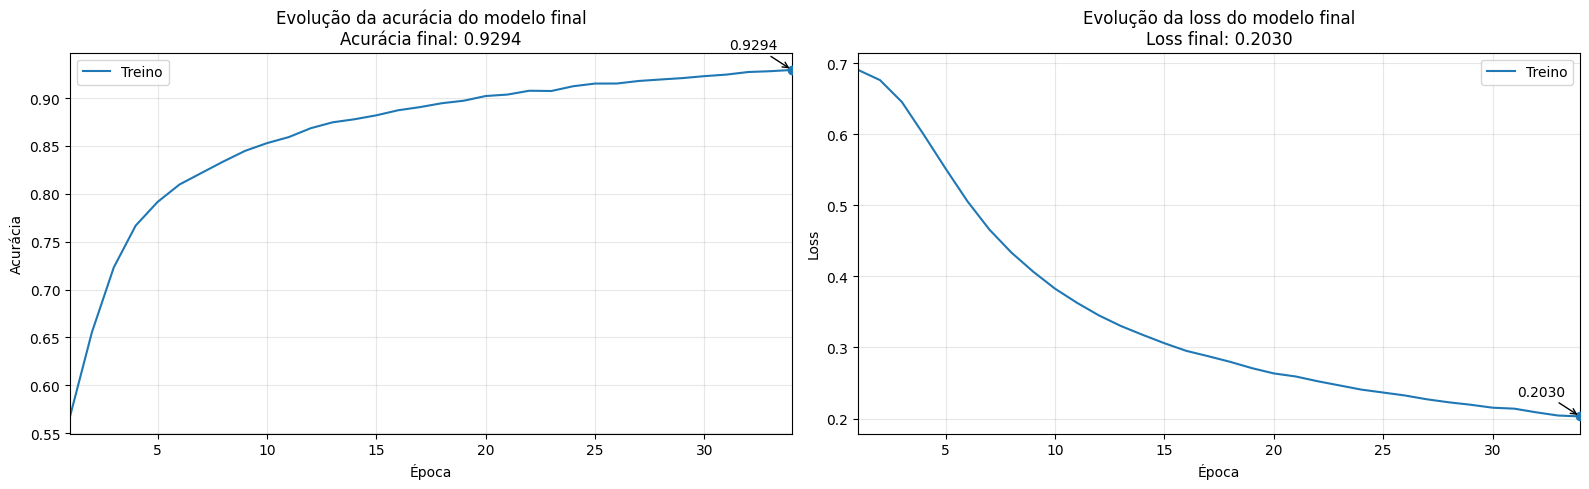

=== Métricas finais de treino ===
Época final : 34
Acurácia    : 0.9294
Loss        : 0.2030


In [62]:
plotar_historico_modelo_final(history_final)

### **6º Passo:**
<font size=3>

- Realize a avaliação do modelo com o método `.evaluate()`;
- **Imprima na tela** 10 predições com seus respectivos valores verdadeiros.

In [63]:
# ============================================================
# Preparação do conjunto de teste
# ============================================================

X_test_final = tf.convert_to_tensor(
    X_test.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

y_test_final = tf.convert_to_tensor(
    y_test.to_numpy(),
    dtype=tf.float32
)

print(f"Formato de X_test_final: {X_test_final.shape}")
print(f"Formato de y_test_final: {y_test_final.shape}")

Formato de X_test_final: (5000, 1)
Formato de y_test_final: (5000,)


Formato de X_test_final: (5000, 1)
Formato de y_test_final: (5000,)
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8994 - loss: 0.2499

=== Avaliação final com model.evaluate() ===
Loss     : 0.2499
Acurácia : 0.8994
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=== Métricas consolidadas no conjunto de teste ===
Acurácia  : 0.8994
Precisão  : 0.8908
Recall    : 0.9104
F1-score  : 0.9005
ROC-AUC   : 0.9629

=== Relatório de classificação ===
              precision    recall  f1-score   support

    Negativa     0.9084    0.8884    0.8983      2500
    Positiva     0.8908    0.9104    0.9005      2500

    accuracy                         0.8994      5000
   macro avg     0.8996    0.8994    0.8994      5000
weighted avg     0.8996    0.8994    0.8994      5000



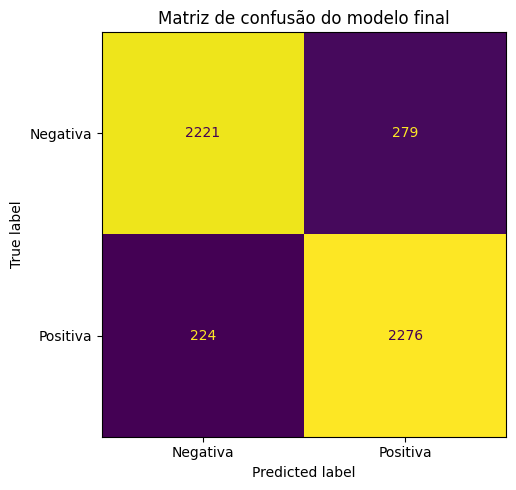

In [67]:
# ============================================================
# Preparação do conjunto de teste
# ============================================================

X_test_final = tf.convert_to_tensor(
    X_test.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

y_test_final = tf.convert_to_tensor(
    y_test.to_numpy(),
    dtype=tf.float32
)

print(f"Formato de X_test_final: {X_test_final.shape}")
print(f"Formato de y_test_final: {y_test_final.shape}")

# ============================================================
# Avaliação do modelo com .evaluate()
# ============================================================

test_loss, test_accuracy = model_final.evaluate(
    X_test_final,
    y_test_final,
    batch_size=FINAL_BATCH_SIZE,
    verbose=1
)

print("\n=== Avaliação final com model.evaluate() ===")
print(f"Loss     : {test_loss:.4f}")
print(f"Acurácia : {test_accuracy:.4f}")


# ============================================================
# Predições sobre todo o conjunto de teste
# ============================================================

y_prob = model_final.predict(
    X_test_final,
    batch_size=FINAL_BATCH_SIZE,
    verbose=1
).reshape(-1)

y_pred = (y_prob >= 0.5).astype(int)
y_true = y_test_final.numpy().astype(int)


# ============================================================
# Métricas consolidadas
# ============================================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print("\n=== Métricas consolidadas no conjunto de teste ===")
print(f"Acurácia  : {accuracy:.4f}")
print(f"Precisão  : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


# ============================================================
# Relatório detalhado por classe
# ============================================================

print("\n=== Relatório de classificação ===")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negativa", "Positiva"],
        digits=4
    )
)


# ============================================================
# Matriz de confusão
# ============================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativa", "Positiva"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("Matriz de confusão do modelo final")

plt.tight_layout()
plt.show()

Executamos a avaliação final sobre o conjunto de teste reservado, composto por 5.000 reviews balanceadas entre as classes positiva e negativa. O modelo obteve acurácia de 0,8994 e loss de 0,2499, mantendo desempenho próximo ao observado durante a etapa de validação.

A matriz de confusão mostra 2.221 reviews negativas e 2.276 reviews positivas classificadas corretamente. Observamos 279 falsos positivos e 224 falsos negativos. O modelo apresentou precisão de 0,8908, recall de 0,9104 e F1-score de 0,9005 para a classe positiva. Considerando ambas as classes, o F1-score macro foi de 0,8994.

O valor de ROC-AUC foi de 0,9629, indicando boa capacidade de separação entre reviews positivas e negativas. Os resultados sugerem que o modelo apresenta desempenho equilibrado entre as classes e capacidade adequada de generalização sobre dados não utilizados durante o treinamento.


A seguir exibimos alguns exemplos de classificações corretas e erradas em cada classe.

In [70]:
def selecionar_predicoes_para_inspecao(
    X_test,
    y_true,
    y_pred,
    y_prob,
    random_state=RANDOM_STATE
):
    """
    Seleciona 10 predições representativas para inspeção manual:

    - 2 verdadeiros positivos;
    - 2 verdadeiros negativos;
    - 3 falsos positivos;
    - 3 falsos negativos.

    Parameters
    ----------
    X_test : pandas.Series
        Reviews originais do conjunto de teste.

    y_true : array-like
        Valores verdadeiros.

    y_pred : array-like
        Classes preditas após aplicação do limiar de decisão.

    y_prob : array-like
        Probabilidades estimadas para a classe positiva.

    random_state : int
        Semente utilizada para garantir reprodutibilidade.

    Returns
    -------
    pandas.DataFrame
        Tabela contendo as amostras selecionadas.
    """
    rng = np.random.default_rng(random_state)

    X_test_reset = X_test.reset_index(drop=True)

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)

    if not (
        len(X_test_reset)
        == len(y_true)
        == len(y_pred)
        == len(y_prob)
    ):
        raise ValueError(
            "X_test, y_true, y_pred e y_prob devem possuir "
            "a mesma quantidade de amostras."
        )

    categorias = {
        "Positiva correta": {
            "indices": np.where(
                (y_true == 1) & (y_pred == 1)
            )[0],
            "quantidade": 2
        },
        "Negativa correta": {
            "indices": np.where(
                (y_true == 0) & (y_pred == 0)
            )[0],
            "quantidade": 2
        },
        "Falso positivo": {
            "indices": np.where(
                (y_true == 0) & (y_pred == 1)
            )[0],
            "quantidade": 3
        },
        "Falso negativo": {
            "indices": np.where(
                (y_true == 1) & (y_pred == 0)
            )[0],
            "quantidade": 3
        }
    }

    registros = []

    for categoria, configuracao in categorias.items():
        indices_disponiveis = configuracao["indices"]
        quantidade = configuracao["quantidade"]

        if len(indices_disponiveis) < quantidade:
            raise ValueError(
                f"A categoria '{categoria}' possui apenas "
                f"{len(indices_disponiveis)} amostras disponíveis, "
                f"mas foram solicitadas {quantidade}."
            )

        indices_selecionados = rng.choice(
            indices_disponiveis,
            size=quantidade,
            replace=False
        )

        for indice in indices_selecionados:
            registros.append({
                "categoria": categoria,
                "índice no teste": indice,
                "valor verdadeiro": y_true[indice],
                "classe predita": y_pred[indice],
                "probabilidade positiva": y_prob[indice],
                "review": X_test_reset.iloc[indice]
            })

    return pd.DataFrame(registros)

In [72]:
df_predicoes_inspecao = selecionar_predicoes_para_inspecao(
    X_test=X_test,
    y_true=y_true,
    y_pred=y_pred,
    y_prob=y_prob,
    random_state=RANDOM_STATE
)

pd.set_option("display.max_colwidth", None)

df_predicoes_inspecao.style.format({
    "probabilidade positiva": "{:.4f}"
})

,categoria,índice no teste,valor verdadeiro,classe predita,probabilidade positiva,review
0,Positiva correta,408,1,1,0.9989,"The Kite Runner was beautiful, poignant and very moving. I particularly loved the two child actors in the film as well as the actor portraying the father. It really made me want to go back and read the book again.The music was a wonderful part of the fabric of the movie. If there is a soundtrack coming out for the film, I will buy it to accompany my second reading of the book. It is also a visually stunning film. The cinematography was gorgeous and really added to experience.The Brazilian word 'saudades' is very descriptive of how I felt at the end of the film...""it is a deep feeling of longing for someone or someplace, which is very sweet but also tinged with an inescapable sadness"" (definition provided years ago by Antonio Carlos Jobim).Saw it at a small cinema here for an advance screening. I would love to see it again on a really large screen with a tricked out sound system.Can't wait for the formal release. I will definitely recommend the film to friends."
1,Positiva correta,3919,1,1,0.7021,"In the area of movies based off of screenplays from some other area (or whatever the title for that Oscar is), ""Holes"" has credibility. I think it is better to have the author create the screenplay because the author is the creator of the material. If the author can't write a screenplay to save their life, then have the author and someone fluently talented in the area of screenwriting create it. Aside from that, this review is about ""Holes"".The reasons start here and a spoiler maybe found within. (1) Louis Sachar is an excellent author and it turns that he can write a screenplay. I watched the movie and then read the book and both didn't reek incoherence or stupidity. Some people just have natural talents that can transcend mediums. (2) The best performance award goes to Shia LaBeouf for his portrayal as the main character. He ""dug"" himself into the role. I wanted to see his character vindicated before the conclusion. (3) To ratchet up the suspense a bit, Andrew Davis was brought in. This is the man that made Harrison Ford run hard and run fast. He also can make Steven Seagal smash some heads. As for this film, he made Shia and the rest of the boys dig some holes. In other words, he can make an ""action-packed"" movie and make it well even if ""action"" isn't the main genre isn't ""action"". (4) My second favorite performance goes to Jon Voight as Mr. Sir. Sometimes a goofy role brings out the best in a performer. When Voight uttered the line ""Once upon a time..."", I must have laughed for half a minute because it was so funny. He is capable of comedy and he should investigate a few more roles that let him to exercise that talent. (5) Tim Blake Nelson is very solid whenever he is given a solid script. This is probably the second best role I have seen him in (second only to 'O Brother Where Art Thou?'). (6) I love the choice of settings for the movie. I didn't know California was that dry or that barren. I guess population and land area figures both can be misleading. (7) The overall look of the movie made me want another bottle of water. One could only imagine digging a hole in that barren area for half a day. (8) The rest of the cast should deserve a box of Kudos bars as well. Sigourney Weaver, Henry Winkler, Khleo Thomas, Jake M. Smith and the rest of the bill were tapped because of their talents and it gelled very well. Great cast even though it was anywhere near ensemble. (9) I like a movie that doesn't explain anything right away. When Stanley got clocked in the head with those baseball cleats, it made me want to see how weird the events could get and that is a key ingredient in making a good movie. (10) Disney Pictures (not Touchstone, DISNEY!!) needs to make a few more of these mature juvenile films. It was palatable for me and I am a college student. The last mature juvenile Disney film I saw was

A inspeção manual das predições mostra que o modelo identifica corretamente reviews com polaridade claramente definida. Textos com predominância de elogios recebem probabilidades elevadas para a classe positiva, enquanto críticas explícitas tendem a ser classificadas corretamente como negativas.

Os erros ocorrem principalmente em reviews ambíguas, que combinam elogios e críticas, ou em textos nos quais palavras negativas descrevem o enredo do filme sem representar uma avaliação desfavorável. Também foram observados casos próximos ao limiar de decisão de `0,5`, indicando baixa confiança do modelo.

Esses resultados são compatíveis com a arquitetura utilizada. A camada `GlobalAveragePooling1D` produz uma representação compacta da review por meio da média dos embeddings, mas não considera diretamente a ordem das palavras, relações de negação ou contrastes entre trechos. Essa limitação pode dificultar a interpretação de textos longos ou semanticamente mais complexos.


### **8º Passo:**
<font size=3>

- Faça o **relatório da modelagem da arquitetura neural** em uma **célula _markdown_**. Descreva alterações que você teve de realizar na arquitetura a fim de aprimorar a performance do predição.
      

Foi desenvolvida uma arquitetura neural para classificação binária de sentimentos em reviews do dataset IMDB. O modelo recebe diretamente uma review textual e produz uma probabilidade associada à classe positiva. Reviews com probabilidade maior ou igual a `0,5` são classificadas como positivas; as demais são classificadas como negativas.


#### Pré-processamento e preparação dos textos

Antes da definição da arquitetura, foi realizada uma análise exploratória dos textos. O pré-processamento adotado converte os caracteres para minúsculas, remove tags HTML, elimina caracteres especiais, normaliza espaços consecutivos e remove espaços excedentes no início e no final das reviews.

A remoção explícita das tags HTML foi necessária porque marcações como `<br />` estavam sendo transformadas no token artificial `br`. Antes desse ajuste, esse token aparecia entre os termos mais frequentes do corpus e introduzia ruído no vocabulário.

A análise do comprimento das reviews mostrou uma distribuição assimétrica à direita. Para evitar que poucos textos excepcionalmente longos determinassem o tamanho de todas as entradas, foi escolhido o percentil 95 da distribuição como limite máximo:

```python
MAX_LENGTH = 581
```

Dessa forma, 95% das reviews são representadas integralmente. Textos maiores são truncados e textos menores recebem preenchimento até atingir o tamanho fixado.

O tamanho do vocabulário também foi definido com base na cobertura acumulada das ocorrências de palavras. A configuração escolhida foi:

```python
VOCAB_SIZE = 15.000
```

Esse valor cobre aproximadamente `95,44%` das ocorrências do corpus, mantendo apenas `4,56%` das palavras fora do vocabulário. A escolha representa um equilíbrio entre cobertura textual e custo computacional.

#### Arquitetura utilizada

A arquitetura final foi composta pelas seguintes camadas:

```text
Entrada textual
→ TextVectorization
→ Embedding
→ GlobalAveragePooling1D
→ Dense
→ Dropout
→ Dense com ativação sigmoid
```

A camada `TextVectorization` aplica o pré-processamento e converte cada review em uma sequência de `581` índices inteiros.

A camada `Embedding` transforma cada índice em um vetor numérico treinável. A dimensão adotada foi:

```python
EMBED_DIM = 50
```

Com um vocabulário de `15.000` palavras, essa camada contém `750.000` parâmetros treináveis.

Após o embedding, foi utilizada a camada `GlobalAveragePooling1D`. Essa camada reduz a matriz de representação de cada review a um único vetor médio. A escolha evita o aumento expressivo da quantidade de parâmetros que ocorreria com uma camada `Flatten`, mantendo a arquitetura mais compacta.

A camada intermediária final possui:

```python
DENSE_UNITS = 16
```

neurônios com ativação `ReLU`. Em seguida, foi aplicado:

```python
DROPOUT_RATE = 0.5
```

para reduzir o sobreajuste observado durante os treinamentos experimentais.

A camada de saída possui um único neurônio com ativação `sigmoid`, adequada ao problema de classificação binária.

#### Ajuste dos hiperparâmetros

A seleção dos hiperparâmetros foi realizada em duas etapas com `KerasTuner`.

Inicialmente, foi executada uma busca aleatória com diferentes valores para:

* dimensão do embedding;
* quantidade de neurônios da camada densa;
* taxa de dropout;
* otimizador;
* taxa de aprendizado.

Essa etapa mostrou que o otimizador `Adam` apresentou desempenho superior às alternativas avaliadas. Também indicou que a dimensão de embedding igual a `50` era suficiente, pois valores maiores não produziram ganhos relevantes e aumentavam significativamente a quantidade de parâmetros.

Na etapa seguinte, foi realizada uma busca exaustiva em um espaço refinado, mantendo fixos o otimizador `Adam` e a dimensão do embedding. Foram avaliadas todas as `36` combinações possíveis entre:

```text
dense_units   = [16, 32, 64]
dropout_rate  = [0.2, 0.3, 0.4, 0.5]
learning_rate = [5e-5, 1e-4, 2e-4]
```

Os modelos com melhor acurácia de validação apresentaram resultados muito próximos. Por esse motivo, a escolha final não considerou apenas o maior valor pontual de acurácia, mas também a estabilidade das curvas de treino e validação, a simplicidade da arquitetura e os sinais de sobreajuste.

Foi selecionada a configuração:

```python
EMBED_DIM = 50
DENSE_UNITS = 16
DROPOUT_RATE = 0.5
LEARNING_RATE = 5e-5
OPTIMIZER = "adam"
```

Essa configuração apresentou convergência mais gradual e menor diferença entre as curvas de treino e validação. Além disso, utiliza uma camada densa menor e maior regularização por dropout, reduzindo a complexidade sem perda relevante de desempenho.

#### Treinamento final e avaliação

Após a seleção da arquitetura, o modelo foi treinado novamente utilizando todas as `45.000` reviews disponíveis no conjunto de treino. O conjunto de teste permaneceu isolado durante as etapas de seleção e ajuste dos hiperparâmetros.

Na avaliação final sobre `5.000` reviews de teste, o modelo obteve:

```text
Loss      = 0,2499
Acurácia  = 0,8994
Precisão  = 0,8908
Recall    = 0,9104
F1-score  = 0,9005
ROC-AUC   = 0,9629
```

A matriz de confusão apresentou:

```text
2.221 reviews negativas classificadas corretamente
2.276 reviews positivas classificadas corretamente
  279 falsos positivos
  224 falsos negativos
```

Os resultados indicam desempenho equilibrado entre as classes e capacidade adequada de generalização sobre dados não utilizados durante o treinamento.
